***RNN (Recurrent Neural Network)*** is a type of neural network that processes sequential data by maintaining a hidden state (memory), 
enabling it to capture context from previous inputs. 
It is widely used in NLP tasks such as language modeling, sentiment analysis, and machine translation.

In [1]:
### Full code for forword PASS + BPTT
import numpy as np
import matplotlib.pyplot as plt

# Step - , Input
words_vectors = {
    "I": ([0.1, 0.2]),
    "love": ([0.5, 0.1]),
    "NLP": ([0.3, 0.7])
}

sentence = ["I", "love", "NLP"]

true_label = np.array([0,1]) ## Class-1, Positive 

In [2]:
### Step 2: RNN parameters

np.random.seed(42)
w_xh = np.array([[0.1, 0.2], [0.3, 0.4]])
w_hh = np.array([[0.5, -0.1], [0.2, 0.6]])
w_hy = np.array([[1.0, -1.2], [-1.0, 1.0]])
b_h = np.zeros(2)
b_y = np.zeros(2)

In [3]:
### Step 3: Forword Pass

def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x/e_x.sum()

H_0 = np.zeros(2)
h_list = [H_0]
x_list = []

In [4]:
### Forword through time

for word in sentence:
    x_t = words_vectors[word]
    x_list.append(x_t)
    h_prev = h_list[-1]
    h_t = np.tanh(np.dot(w_hy, x_t) + np.dot(w_hh, h_prev) + b_h)
    h_list.append(h_t)
    ## Final predictions
    logits = np.dot(w_hy, h_list[-1], + b_y)

    y_pred = softmax(logits)
    inital_loss = -np.log(y_pred[np.argmax(true_label)])

In [5]:
### Backwordpropagation through time
d_logits =  y_pred - true_label

## gradients for the output weights
dw_hy = np.outer(d_logits, h_list[-1])
db_y = d_logits.copy()
dh_next = np.dot(w_xh.T, d_logits)

## initialize the RNN gradients
dw_xh = np.zeros_like(w_xh)
dw_hh = np.zeros_like(w_hh)
db_h = np.zeros_like(b_h)


In [6]:
#### BPPT
for t in reversed(range(len(sentence))):
    h_t = h_list[t+1]
    h_prev = h_list[t]
    x_t = x_list[t]
    dz = (1 - h_t**2)
    db_h += dz
    dw_xh += np.outer(dz, x_t)
    dw_hh += np.outer(dz, h_prev)

    dh_next += np.dot(w_hh.T, dz)

In [9]:
### update weights

learning_rate = 0.1 
w_xh -= learning_rate * dw_xh
w_hh -= learning_rate * dw_hh
w_hy -= learning_rate  * dw_hy


b_h -= learning_rate * db_h
b_y -= learning_rate * db_y

In [11]:
### Forward pass after the up

h_0 = np.zeros(2)
h_list = [h_0]
x_list = []

for word in sentence:
    x_t  = words_vectors[word]
    x_list.append(x_t)
    h_prev = h_list[-1]
    h_t = np.tanh(np.dot(w_xh, x_t) + np.dot(w_hh, h_prev) + b_h)
    h_list.append(h_t)


logits = np.dot(w_hy, h_list[-1] + b_y)
y_pred = softmax(logits)
updated_loss = -np.log(y_pred[np.argmax(true_label)])

In [13]:
print("Loss before: ", round(inital_loss, 4))
print("Loss after update: ", round(updated_loss, 4))

Loss before:  0.2584
Loss after update:  0.6726


In [15]:
graidiets = {
    "dw_xh": np.linalg.norm(dw_xh),
    "dw_hh": np.linalg.norm(dw_hh),
    "dw_hy": np.linalg.norm(dw_hy),
    "db_h":  np.linalg.norm(db_h),
    "db_y" : np.linalg.norm(db_y)
}

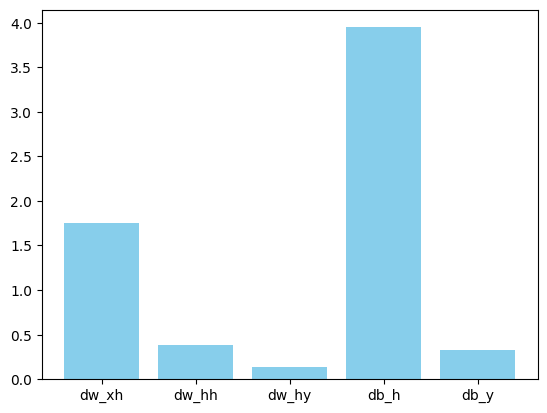

In [16]:
plt.bar(graidiets.keys(), graidiets.values(), color='skyblue')
plt.show()